In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from data import load_data, regions, popls

plt.rcParams['font.family'] = 'DejaVu Sans Mono'

df = load_data()
genes = [el for el in df.columns if el.startswith('rs')]
# regions = sorted(df['region'].unique())
# popls = sorted(df['popl'].unique())

df_chs = []
for ch in 'ACGT':
    df_ch = dict()
    for gene, col in df[genes].iteritems():
        tmp = col.str.count(ch)
        tmp[col == 'NN'] = np.nan
        df_ch[f'{gene}_{ch}'] = tmp
    df_ch = pd.DataFrame(df_ch, dtype=np.float32)
    df_chs.append(df_ch)
df_chs = pd.concat(df_chs, axis=1).sort_index(axis=1)

In [2]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import StratifiedKFold, train_test_split

ordinal_encoder = OrdinalEncoder()
Xcat = ordinal_encoder.fit_transform(df[genes].values.astype('<U2'))

one_hot_encoder = OneHotEncoder(sparse=False)
Xoh = one_hot_encoder.fit_transform(df[genes].values.astype('<U2'))
grps_xoh = df[genes].nunique().values

Xnum = df_chs.loc[:, df_chs.nunique(dropna=False) > 1].values
grps_xnum = np.sum( (df_chs.nunique(dropna=False) > 1).values.reshape(-1, 4) , axis=-1)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['region'])

def cv_splitter(X, y, strat, n_splits, shuffle=True, random_state=None):
    for train_idxs, test_idxs in StratifiedKFold(n_splits=n_splits, shuffle=shuffle, random_state=random_state).split(X, strat):
        yield X[train_idxs], X[test_idxs], y[train_idxs], y[test_idxs], strat[train_idxs], strat[test_idxs]

def group_sum(arr, grp_sizes):
    assert arr.shape[-1] == np.sum(grp_sizes)
    result = []
    lb = 0
    for grp_size in grp_sizes:
        result.append( np.sum(arr[..., lb:lb+grp_size], axis=-1) )
        lb += grp_size
    result = np.stack(result, axis=-1)
    return result

def ungroup(arr, grp_sizes):
    result = []
    cumsum = np.insert(np.cumsum(grp_sizes), 0, 0)
    for i in arr:
        result.append(np.arange(cumsum[i], cumsum[i+1]))
    return np.concatenate(result)

In [3]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, classification_report

n_splits = 5
n_SNPs = (50, 75, 100, 125, 150, Xcat.shape[1])

## LR, SVM, KNN, MultinomialNB

In [4]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import KNNImputer
from sklearn.metrics.pairwise import distance_metrics

def nan_l1_dist(X, Y, missing_values=np.nan):
    # if Y is None:
    #     Y = X
    # assert np.isnan(missing_values)

    diff = X - Y
    na_count = np.sum(np.isnan(diff))
    distance = np.nansum(np.abs(diff))
    distance *= (X.shape[-1] / (X.shape[-1]-na_count))
    return distance

    # X_fill = np.nan_to_num(X)
    # Y_fill = np.nan_to_num(Y)
    # distances = distance_metrics()['manhattan'](X_fill, Y_fill)
    # distances -= np.dot(np.abs(X_fill), np.isnan(Y).T)
    # distances -= np.dot(np.isnan(X), np.abs(Y_fill).T)
    
    # notna_count = np.dot(~np.isnan(X), ~np.isnan(Y).T)
    # distances[notna_count == 0] = np.nan
    # distances /= np.maximum(1, notna_count)
    # distances *= X.shape[-1]

    # return distances    

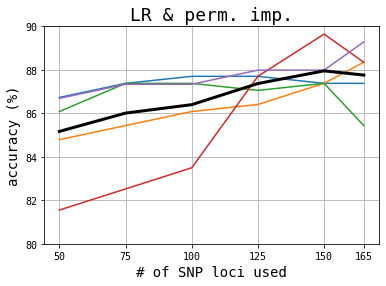

In [7]:
from sklearn.linear_model import LogisticRegression

lr_params = {
    'knnimputer__n_neighbors': 45,
    'knnimputer__metric': nan_l1_dist,
    'logisticregression__penalty': 'elasticnet',
    'logisticregression__C': 0.029598512368422047,
    'logisticregression__l1_ratio': 0.23215770943111214
}

val_scores_abs = np.empty((n_splits, len(n_SNPs)))
val_scores_rel = np.empty((n_splits, 5))
n_rel_imp_vars = np.empty((n_splits, 5), dtype=np.int32)

for i, (X_train, X_test, y_train, y_test, p_train, _) in enumerate(cv_splitter(Xnum, y, df['popl'], n_splits=n_splits, random_state=42)):
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, stratify=p_train, random_state=42)
    imputer = KNNImputer(
        n_neighbors=45, 
        metric=nan_l1_dist
    )
    X_train = imputer.fit_transform(X_train)
    X_val = imputer.transform(X_val)
    X_test = imputer.transform(X_test)

    model = LogisticRegression(
        penalty='elasticnet',
        C=0.029598512368422047, 
        l1_ratio=0.23215770943111214,
        solver='saga', 
        max_iter=1000,
        multi_class='multinomial',
        random_state=42
    )
    model.fit(X_train, y_train)
    # fi = np.sum(np.abs(model.coef_), axis=0)
    pi = permutation_importance(model, X_val, y_val, scoring='accuracy', n_repeats=30, random_state=42)
    fi = pi['importances_mean']
    fi = group_sum(fi, grps_xnum)

    for j in range(len(n_SNPs)):
        n_SNP = n_SNPs[j]
        choice = ungroup(np.argsort(fi)[-n_SNP:], grps_xnum)
        model.fit(X_train[:, choice], y_train)
        val_scores_abs[i, j] = accuracy_score(y_test, model.predict(X_test[:, choice]))
val_scores_abs *= 100

plt.figure(figsize=(6, 4))
for i in range(n_splits):
    plt.plot(n_SNPs, val_scores_abs[i])
plt.plot(n_SNPs, np.mean(val_scores_abs, axis=0), color='#000000', linewidth=3)
plt.title('LR & perm. imp.', fontsize=18)
plt.xlabel('# of SNP loci used', fontsize=14); plt.xticks(n_SNPs)
plt.ylabel('accuracy (%)', fontsize=14); plt.ylim(80, 90)
plt.grid(); plt.show(); plt.close()

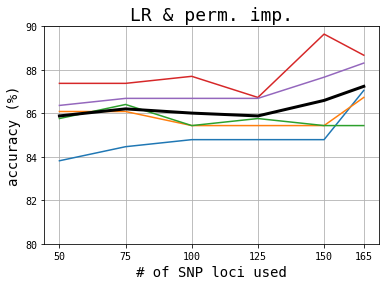

In [8]:
from sklearn.linear_model import LogisticRegression

lr_params = {
    'knnimputer__n_neighbors': 45,
    'knnimputer__metric': nan_l1_dist,
    'logisticregression__penalty': 'elasticnet',
    'logisticregression__C': 0.029598512368422047,
    'logisticregression__l1_ratio': 0.23215770943111214
}

val_scores_abs = np.empty((n_splits, len(n_SNPs)))
val_scores_rel = np.empty((n_splits, 5))
n_rel_imp_vars = np.empty((n_splits, 5), dtype=np.int32)

for i, (X_train, X_test, y_train, y_test, p_train, _) in enumerate(cv_splitter(Xnum, y, df['popl'], n_splits=n_splits, random_state=42)):
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, stratify=p_train, random_state=42)
    imputer = KNNImputer(
        n_neighbors=45, 
        metric=nan_l1_dist
    )
    X_train = imputer.fit_transform(X_train)
    X_val = imputer.transform(X_val)
    X_test = imputer.transform(X_test)

    model = LogisticRegression(
        penalty='elasticnet',
        C=0.029598512368422047, 
        l1_ratio=0.23215770943111214,
        solver='saga', 
        max_iter=1000,
        multi_class='ovr',
        random_state=42
    )
    model.fit(X_train, y_train)
    # fi = np.sum(np.abs(model.coef_), axis=0)
    pi = permutation_importance(model, X_val, y_val, scoring='accuracy', n_repeats=30, random_state=42)
    fi = pi['importances_mean']
    fi = group_sum(fi, grps_xnum)

    for j in range(len(n_SNPs)):
        n_SNP = n_SNPs[j]
        choice = ungroup(np.argsort(fi)[-n_SNP:], grps_xnum)
        model.fit(X_train[:, choice], y_train)
        val_scores_abs[i, j] = accuracy_score(y_test, model.predict(X_test[:, choice]))
val_scores_abs *= 100

plt.figure(figsize=(6, 4))
for i in range(n_splits):
    plt.plot(n_SNPs, val_scores_abs[i])
plt.plot(n_SNPs, np.mean(val_scores_abs, axis=0), color='#000000', linewidth=3)
plt.title('LR & perm. imp.', fontsize=18)
plt.xlabel('# of SNP loci used', fontsize=14); plt.xticks(n_SNPs)
plt.ylabel('accuracy (%)', fontsize=14); plt.ylim(80, 90)
plt.grid(); plt.show(); plt.close()

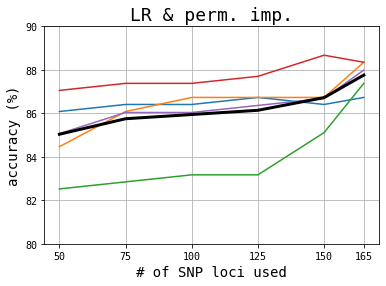

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsOneClassifier

lr_params = {
    'knnimputer__n_neighbors': 45,
    'knnimputer__metric': nan_l1_dist,
    'logisticregression__penalty': 'elasticnet',
    'logisticregression__C': 0.029598512368422047,
    'logisticregression__l1_ratio': 0.23215770943111214
}

val_scores_abs = np.empty((n_splits, len(n_SNPs)))
val_scores_rel = np.empty((n_splits, 5))
n_rel_imp_vars = np.empty((n_splits, 5), dtype=np.int32)

for i, (X_train, X_test, y_train, y_test, p_train, _) in enumerate(cv_splitter(Xnum, y, df['popl'], n_splits=n_splits, random_state=42)):
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, stratify=p_train, random_state=42)
    imputer = KNNImputer(
        n_neighbors=45, 
        metric=nan_l1_dist
    )
    X_train = imputer.fit_transform(X_train)
    X_val = imputer.transform(X_val)
    X_test = imputer.transform(X_test)

    model = OneVsOneClassifier(LogisticRegression(
        penalty='elasticnet',
        C=0.029598512368422047, 
        l1_ratio=0.23215770943111214,
        solver='saga', 
        max_iter=1000,
        multi_class='ovr',
        random_state=42
    ))
    model.fit(X_train, y_train)
    # fi = np.sum(np.abs(model.coef_), axis=0)
    pi = permutation_importance(model, X_val, y_val, scoring='accuracy', n_repeats=30, random_state=42)
    fi = pi['importances_mean']
    fi = group_sum(fi, grps_xnum)

    for j in range(len(n_SNPs)):
        n_SNP = n_SNPs[j]
        choice = ungroup(np.argsort(fi)[-n_SNP:], grps_xnum)
        model.fit(X_train[:, choice], y_train)
        val_scores_abs[i, j] = accuracy_score(y_test, model.predict(X_test[:, choice]))
val_scores_abs *= 100

plt.figure(figsize=(6, 4))
for i in range(n_splits):
    plt.plot(n_SNPs, val_scores_abs[i])
plt.plot(n_SNPs, np.mean(val_scores_abs, axis=0), color='#000000', linewidth=3)
plt.title('LR & perm. imp.', fontsize=18)
plt.xlabel('# of SNP loci used', fontsize=14); plt.xticks(n_SNPs)
plt.ylabel('accuracy (%)', fontsize=14); plt.ylim(80, 90)
plt.grid(); plt.show(); plt.close()

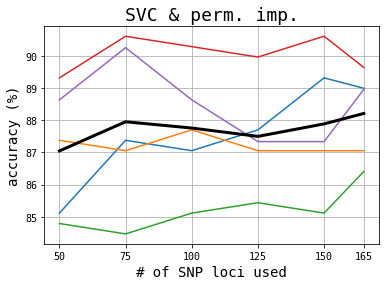

In [10]:
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier

svc_params = {
    'knnimputer__n_neighbors': 12,
    'knnimputer__metric': 'nan_euclidean',
    'svc__C': 0.3289812567312727,
    'svc__kernel': 'poly',
    'svc__degree': 8,
    'svc__gamma': 'auto'
}
val_scores_abs = np.empty((n_splits, len(n_SNPs)))
val_scores_rel = np.empty((n_splits, 5))
n_rel_imp_vars = np.empty((n_splits, 5), dtype=np.int32)

for i, (X_train, X_test, y_train, y_test, p_train, _) in enumerate(cv_splitter(Xnum, y, df['popl'], n_splits=n_splits, random_state=42)):
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, stratify=p_train, random_state=42)
    imputer = KNNImputer(
        n_neighbors=12, 
        metric='nan_euclidean'
    )
    X_train = imputer.fit_transform(X_train)
    X_val = imputer.transform(X_val)
    X_test = imputer.transform(X_test)

    model = OneVsRestClassifier(SVC(
        C=0.3289812567312727, 
        kernel='poly',
        degree=8,
        gamma='auto',
        # coef0=0.0,
        random_state=42
    ))
    model.fit(X_train, y_train)

    pi = permutation_importance(model, X_val, y_val, scoring='accuracy', n_repeats=30, random_state=42)
    fi = pi['importances_mean']
    fi = group_sum(fi, grps_xnum)
    
    for j in range(len(n_SNPs)):
        n_SNP = n_SNPs[j]
        choice = ungroup(np.argsort(fi)[-n_SNP:], grps_xnum)
        model.fit(X_train[:, choice], y_train)
        val_scores_abs[i, j] = accuracy_score(y_test, model.predict(X_test[:, choice]))
val_scores_abs *= 100

plt.figure(figsize=(6, 4))
for i in range(n_splits):
    plt.plot(n_SNPs, val_scores_abs[i])
plt.plot(n_SNPs, np.mean(val_scores_abs, axis=0), color='#000000', linewidth=3)
plt.title('SVC & perm. imp.', fontsize=18)
plt.xlabel('# of SNP loci used', fontsize=14); plt.xticks(n_SNPs)
plt.ylabel('accuracy (%)', fontsize=14)
plt.grid(); plt.show(); plt.close()

## What about DNN?

In [12]:
from sklearn.neural_network import MLPClassifier

models_mlp = []
print('train\ttest')
for X_train, X_test, y_train, y_test in cv_splitter(Xnum, y, df['popl'], n_splits=5, random_state=42):
    model = make_pipeline(
        KNNImputer(
            n_neighbors=5, 
            metric=nan_l1_dist
        ),
        MLPClassifier(
            hidden_layer_sizes=(128, 32, ),
            alpha=1e-2,
            max_iter=2000,
        )
    )
    model.fit(X_train, y_train)
    models_mlp.append(model)
    print(
        '%.2f%%' % (100*np.mean(model.predict(X_train) == y_train)), '\t',
        '%.2f%%' % (100*np.mean(model.predict(X_test) == y_test)), sep=''
    )

train	test
99.92%	88.35%
99.92%	86.41%
100.00%	88.67%
100.00%	91.59%
99.92%	87.34%
